In [2]:
import pandas as pd
import numpy as np

In [3]:
#Creating a DataFrame from a Dictionary
data = {
    'Name': ['Alice', 'Bob', 'Charlie', 'David', 'Eve'],
    'Age': [24, 27, 22, 32, 29],
    'City': ['New York', 'Los Angeles', 'Chicago', 'Houston', 'Phoenix'],
    'Occupation': ['Engineer', 'Doctor', 'Artist', 'Scientist', 'Teacher']
}
df_dict = pd.DataFrame(data)
print("DataFrame from Dictionary:")
display(df_dict)

DataFrame from Dictionary:


,Name,Age,City,Occupation
0,Alice,24,New York,Engineer
1,Bob,27,Los Angeles,Doctor
2,Charlie,22,Chicago,Artist
3,David,32,Houston,Scientist
4,Eve,29,Phoenix,Teacher


In [4]:
#Creating a DataFrame from a List of Lists (with columns)
data_list = [
    ['Alice', 24, 'New York'],
    ['Bob', 27, 'Los Angeles'],
    ['Charlie', 22, 'Chicago']
]
columns_list = ['Name', 'Age', 'City']
df_list = pd.DataFrame(data_list, columns=columns_list)
print("DataFrame from List of Lists:")
display(df_list)

DataFrame from List of Lists:


,Name,Age,City
0,Alice,24,New York
1,Bob,27,Los Angeles
2,Charlie,22,Chicago


In [5]:
#Creating a DataFrame from a NumPy Array
data_np = np.array([[10,20,30], [40,50,60], [70,80,90]])
df_np = pd.DataFrame(data_np, columns = ['col1','col2','col3'])
print("DataFrame from Numpy Array:")
display(df_np)

DataFrame from Numpy Array:


,col1,col2,col3
0,10,20,30
1,40,50,60
2,70,80,90


In [6]:
# 2. Basic DataFrame Operations
df = df_dict.copy()
print("###Displaying Data")
print("First  3 rows (head):")
display(df.head(3))

print("Last 2 rows (tail):")
display(df.tail(2))

print("DataFrame Info (data types, non-null counts):")
df.info()

print("Descriptive Statistics (for numerical coloumns):")
display(df.describe())

###Displaying Data
First  3 rows (head):


,Name,Age,City,Occupation
0,Alice,24,New York,Engineer
1,Bob,27,Los Angeles,Doctor
2,Charlie,22,Chicago,Artist


Last 2 rows (tail):


,Name,Age,City,Occupation
3,David,32,Houston,Scientist
4,Eve,29,Phoenix,Teacher


DataFrame Info (data types, non-null counts):
<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Name        5 non-null      str  
 1   Age         5 non-null      int64
 2   City        5 non-null      str  
 3   Occupation  5 non-null      str  
dtypes: int64(1), str(3)
memory usage: 292.0 bytes
Descriptive Statistics (for numerical coloumns):


,Age
count,5.000000
mean,26.800000
std,3.962323
min,22.000000
25%,24.000000
50%,27.000000
75%,29.000000
max,32.000000


In [7]:
print("###selecting columns")

print("single column 'Name':")
print(df['Name'])

print("Multiple coloumns ['Name', 'Age']:")
display(df[['Name', 'Age']])

###selecting columns
single column 'Name':
0      Alice
1        Bob
2    Charlie
3      David
4        Eve
Name: Name, dtype: str
Multiple coloumns ['Name', 'Age']:


,Name,Age
0,Alice,24
1,Bob,27
2,Charlie,22
3,David,32
4,Eve,29


In [8]:
print("### Adding and modifying coloumns")

# Add a new column
df['Salary'] = [70000, 85000, 60000, 95000, 78000]
print("DataFrame after adding 'salary' colomn:" )
display(df)

# Modify an existing column
df['Age'] = df['Age']+1
print("DataFrame after adding 'Age' colomn:")

# Add a column based on existing ones
df['Age_Category'] = pd.cut(df['Age'], bins = [0,25,30,100], labels=['Young', 'Adult', 'Senior'])
print("DataFrame after adding 'Age_Category' column:")
display(df)

### Adding and modifying coloumns
DataFrame after adding 'salary' colomn:


,Name,Age,City,Occupation,Salary
0,Alice,24,New York,Engineer,70000
1,Bob,27,Los Angeles,Doctor,85000
2,Charlie,22,Chicago,Artist,60000
3,David,32,Houston,Scientist,95000
4,Eve,29,Phoenix,Teacher,78000


DataFrame after adding 'Age' colomn:
DataFrame after adding 'Age_Category' column:


,Name,Age,City,Occupation,Salary,Age_Category
0,Alice,25,New York,Engineer,70000,Young
1,Bob,28,Los Angeles,Doctor,85000,Adult
2,Charlie,23,Chicago,Artist,60000,Young
3,David,33,Houston,Scientist,95000,Senior
4,Eve,30,Phoenix,Teacher,78000,Adult


In [9]:
print("###Filtering rows")

# Filter rows where Age > 25
print("Rows where age > 25:")
display(df[df['Age'] > 25])

# Filter rows for a specific City
print("Rows where City is 'New York':")
display(df[df['City'] == 'New York'])

# Filter rows with multiple conditions
print("Rows where Age > 25 & city is 'Los Angeles':")
display(df[(df['Age'] > 25) & (df['City'] == 'Los Angeles')])



###Filtering rows
Rows where age > 25:


,Name,Age,City,Occupation,Salary,Age_Category
1,Bob,28,Los Angeles,Doctor,85000,Adult
3,David,33,Houston,Scientist,95000,Senior
4,Eve,30,Phoenix,Teacher,78000,Adult


Rows where City is 'New York':


,Name,Age,City,Occupation,Salary,Age_Category
0,Alice,25,New York,Engineer,70000,Young


Rows where Age > 25 & city is 'Los Angeles':


,Name,Age,City,Occupation,Salary,Age_Category
1,Bob,28,Los Angeles,Doctor,85000,Adult


In [10]:
# 3. Handling Missing Data

df_missing = df.copy()
df_missing.loc[1, 'Age'] = np.nan
df_missing.loc[3, 'Occupation'] = np.nan
df_missing.loc[0, 'Salary'] = np.nan

print("DataFrame with introduced missing values:")
display(df_missing)

print("### Identifying Missing Values")
print("df.isnull():")
display(df_missing.isnull())

print("df.isnull().sum() (count of missing values per clmn):")
display(df_missing.isnull().sum())

DataFrame with introduced missing values:


,Name,Age,City,Occupation,Salary,Age_Category
0,Alice,25.0,New York,Engineer,NaN,Young
1,Bob,NaN,Los Angeles,Doctor,85000.0,Adult
2,Charlie,23.0,Chicago,Artist,60000.0,Young
3,David,33.0,Houston,NaN,95000.0,Senior
4,Eve,30.0,Phoenix,Teacher,78000.0,Adult


### Identifying Missing Values
df.isnull():


,Name,Age,City,Occupation,Salary,Age_Category
0,False,False,False,False,True,False
1,False,True,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,True,False,False
4,False,False,False,False,False,False


df.isnull().sum() (count of missing values per clmn):


Name            0
Age             1
City            0
Occupation      1
Salary          1
Age_Category    0
dtype: int64

In [11]:
print("###Filling missing values")

# Fill missing 'Age' with the mean age
df_filled_mean = df_missing.copy()
df_filled_mean['Age'] = df_filled_mean['Age'].fillna(df_filled_mean['Age'].mean())
display(df_filled_mean)

df_filled_value = df_missing.copy()
df_filled_value['Occupation'] = df_filled_value['Occupation'].fillna('Unknown')
print("Filled 'Occupation' with 'Unknown':")
display(df_filled_value)

###Filling missing values


,Name,Age,City,Occupation,Salary,Age_Category
0,Alice,25.00,New York,Engineer,NaN,Young
1,Bob,27.75,Los Angeles,Doctor,85000.0,Adult
2,Charlie,23.00,Chicago,Artist,60000.0,Young
3,David,33.00,Houston,NaN,95000.0,Senior
4,Eve,30.00,Phoenix,Teacher,78000.0,Adult


Filled 'Occupation' with 'Unknown':


,Name,Age,City,Occupation,Salary,Age_Category
0,Alice,25.0,New York,Engineer,NaN,Young
1,Bob,NaN,Los Angeles,Doctor,85000.0,Adult
2,Charlie,23.0,Chicago,Artist,60000.0,Young
3,David,33.0,Houston,Unknown,95000.0,Senior
4,Eve,30.0,Phoenix,Teacher,78000.0,Adult


In [12]:
print("### Dropping Missing Values")

# Drop rows with any missing values
df_dropped_rows = df_missing.dropna()
print("DataFrame after dropping rows with any NaN:")
display(df_dropped_rows)

#Drop colomns with any missing values
df_dropped_cols = df_missing.dropna(axis = 1)
print("DataFrame after dropping columns with any NaN:")
display(df_dropped_cols)

### Dropping Missing Values
DataFrame after dropping rows with any NaN:


,Name,Age,City,Occupation,Salary,Age_Category
2,Charlie,23.0,Chicago,Artist,60000.0,Young
4,Eve,30.0,Phoenix,Teacher,78000.0,Adult


DataFrame after dropping columns with any NaN:


,Name,City,Age_Category
0,Alice,New York,Young
1,Bob,Los Angeles,Adult
2,Charlie,Chicago,Young
3,David,Houston,Senior
4,Eve,Phoenix,Adult


In [13]:
# Category: Grouping and Aggregation
# Create a DataFrame for grouping examples

df_sales_data = pd.DataFrame({
    'Region' : ['East', 'West' , 'East', 'West', 'East', 'West'],
    'Product': ['A', 'B', 'A', 'C', 'B', 'A'],
    'Sales': [100, 150, 120, 200, 130, 110],
    'Units': [10, 15, 12, 20, 13, 11]
})
print("Original Sales Data for Grouping:")
display(df_sales_data)

Original Sales Data for Grouping:


,Region,Product,Sales,Units
0,East,A,100,10
1,West,B,150,15
2,East,A,120,12
3,West,C,200,20
4,East,B,130,13
5,West,A,110,11


In [14]:
# Function: .groupby().mean() (Basic aggregation)
print("Mean Sales by Region:")
display(df_sales_data.groupby('Region')['Sales'].mean())

Mean Sales by Region:


Region
East    116.666667
West    153.333333
Name: Sales, dtype: float64

In [15]:
# Function: .groupby().agg() (Multiple aggregations)
print("Sales statistics (sum, mean, max) by region and product:")
display(df_sales_data.groupby(['Region','Product'])['Sales'].agg(['sum', 'mean', 'max']))

Sales statistics (sum, mean, max) by region and product:


sum   mean  max
Region Product                 
East   A        220  110.0  120
       B        130  130.0  130
West   A        110  110.0  110
       B        150  150.0  150
       C        200  200.0  200

In [16]:
# Function: .groupby().agg() (Multiple aggregations)
print("Sales statistics (sum, mean, max) by region and product:")
display(df_sales_data.groupby(['Product','Region'])['Sales'].agg(['sum', 'mean', 'max']))

Sales statistics (sum, mean, max) by region and product:


sum   mean  max
Product Region                 
A       East    220  110.0  120
        West    110  110.0  110
B       East    130  130.0  130
        West    150  150.0  150
C       West    200  200.0  200

In [17]:
# Function: .value_counts() (Counting unique values)
print("Count of each Product sold:")
display(df_sales_data['Product'].value_counts())

Count of each Product sold:


Product
A    3
B    2
C    1
Name: count, dtype: int64

In [18]:
display(df_sales_data.value_counts())

Region  Product  Sales  Units
East    A        100    10       1
West    B        150    15       1
East    A        120    12       1
West    C        200    20       1
East    B        130    13       1
West    A        110    11       1
Name: count, dtype: int64

In [19]:
# Category: Merging and Joining DataFrames

df_employees = pd.DataFrame({
    'EmpID' : [1,2,3,4],
    'Name' : ['Alice', 'Bob', 'Charlie', 'David'],
    'Department' : ['HR', 'IT', 'Finance', 'HR']
})
df_salaries = pd.DataFrame({
    'EmpID': [1,2,3,5],
    'Salary':[70000, 80000, 60000, 90000]
})
print("df_employees:")
display(df_employees)
print("df_salaries:")
display(df_salaries)

df_employees:


,EmpID,Name,Department
0,1,Alice,HR
1,2,Bob,IT
2,3,Charlie,Finance
3,4,David,HR


df_salaries:


,EmpID,Salary
0,1,70000
1,2,80000
2,3,60000
3,5,90000


In [20]:
# Function: pd.merge() (Inner Join - default)
print("Inner join of employees and salaries on 'EmpID' (only matching IDs):")
display(pd.merge(df_employees,df_salaries,on='EmpID'))

Inner join of employees and salaries on 'EmpID' (only matching IDs):


,EmpID,Name,Department,Salary
0,1,Alice,HR,70000
1,2,Bob,IT,80000
2,3,Charlie,Finance,60000


In [21]:
# Function: pd.merge(how='left') (Left Join)
print("Left join of employees and salaries on 'EmpID' (keep all employees):")
display(pd.merge(df_employees, df_salaries, on='EmpID', how='left'))

Left join of employees and salaries on 'EmpID' (keep all employees):


,EmpID,Name,Department,Salary
0,1,Alice,HR,70000.0
1,2,Bob,IT,80000.0
2,3,Charlie,Finance,60000.0
3,4,David,HR,NaN


In [22]:
# Function: pd.concat() (Concatenating DataFrames)
df_new_employees = pd.DataFrame({
    'EmpID': [5, 6],
    'Name': ['Eve', 'Frank'],
    'Department': ['IT', 'Marketing']
})
print("Vertically concatenate df_employees and df_new_employees:")
display(pd.concat([df_employees, df_new_employees],ignore_index = True))

Vertically concatenate df_employees and df_new_employees:


,EmpID,Name,Department
0,1,Alice,HR
1,2,Bob,IT
2,3,Charlie,Finance
3,4,David,HR
4,5,Eve,IT
5,6,Frank,Marketing


In [23]:
# Category: Pivoting and Reshaping Data
df_pivot_data = pd.DataFrame({
    'Date': ['2023-01-01', '2023-01-01', '2023-01-02', '2023-01-02'],
    'City': ['NY', 'LA', 'NY', 'LA'],
    'Product': ['A', 'B', 'A', 'C'],
    'Sales': [100, 150, 120, 200]
})
print("Original Data for Pivoting:")
display(df_pivot_data)

Original Data for Pivoting:


,Date,City,Product,Sales
0,2023-01-01,NY,A,100
1,2023-01-01,LA,B,150
2,2023-01-02,NY,A,120
3,2023-01-02,LA,C,200


In [24]:
print("Total Sales by City for each Product using pivot_table:")
display(df_pivot_data.pivot_table(values='Sales',index='City',columns='Product',aggfunc='sum'))

Total Sales by City for each Product using pivot_table:


Product,A,B,C
City,,,
LA,NaN,150.0,200.0
NY,220.0,NaN,NaN


In [25]:
# Function: .stack() and .unstack()

df_stack_unstack = df_pivot_data.set_index(['Date','City','Product'])
print("Multi-indexed DataFrame:")
display(df_stack_unstack)

print("Stacked DataFrame (Product level moved to rows):")
display(df_stack_unstack.stack())

print("Unstacked DataFrame (Product level moved to columns):")
display(df_stack_unstack.unstack(level = 'Product'))

Multi-indexed DataFrame:


Sales
Date       City Product       
2023-01-01 NY   A          100
           LA   B          150
2023-01-02 NY   A          120
           LA   C          200

Stacked DataFrame (Product level moved to rows):


Date        City  Product       
2023-01-01  NY    A        Sales    100
            LA    B        Sales    150
2023-01-02  NY    A        Sales    120
            LA    C        Sales    200
dtype: int64

Unstacked DataFrame (Product level moved to columns):


Sales              
Product              A      B      C
Date       City                     
2023-01-01 LA      NaN  150.0    NaN
           NY    100.0    NaN    NaN
2023-01-02 LA      NaN    NaN  200.0
           NY    120.0    NaN    NaN

In [26]:
# 4. Grouping and Aggregating Data
print('###Grouping by a column and calaculating Mean')
data = {
    'Name': ['Alice', 'Bob', 'Charlie', 'David', 'Eve', 'Frank', 'Grace', 'Heidi'],
    'Age': [24, 27, 22, 32, 29, 24, 32,27],
    'City': ['New York', 'Los Angeles', 'Chicago', 'Houston', 'Phoenix', 'New York', 'Los Angeles', 'Chicago'],
    'Occupation': ['Engineer', 'Doctor', 'Artist', 'Scientist', 'Teacher', 'Engineer', 'Scientist', 'Artist'],
    'Salary': [70000, 85000, 60000, 95000, 78000, 72000, 98000, 62000]
}
df_group = pd.DataFrame(data)
display(df_group)

print("Mean Salary by City:")
display(df_group.groupby('City')['Salary'].mean())

print("Mean Age and Salary by Occupation:")
display(df_group.groupby('Occupation')[['Age','Salary']].mean())

print("### Aggregating Multiple Functions")
print("Aggregating count, mean, and max salary by City:")
display(df_group.groupby('City')['Salary'].agg(['count', 'mean','max']))

print("### Value Counts")
print("Count of each Occupation:")
display(df_group['Occupation'].value_counts())

###Grouping by a column and calaculating Mean


,Name,Age,City,Occupation,Salary
0,Alice,24,New York,Engineer,70000
1,Bob,27,Los Angeles,Doctor,85000
2,Charlie,22,Chicago,Artist,60000
3,David,32,Houston,Scientist,95000
4,Eve,29,Phoenix,Teacher,78000
5,Frank,24,New York,Engineer,72000
6,Grace,32,Los Angeles,Scientist,98000
7,Heidi,27,Chicago,Artist,62000


Mean Salary by City:


City
Chicago        61000.0
Houston        95000.0
Los Angeles    91500.0
New York       71000.0
Phoenix        78000.0
Name: Salary, dtype: float64

Mean Age and Salary by Occupation:


,Age,Salary
Occupation,,
Artist,24.5,61000.0
Doctor,27.0,85000.0
Engineer,24.0,71000.0
Scientist,32.0,96500.0
Teacher,29.0,78000.0


### Aggregating Multiple Functions
Aggregating count, mean, and max salary by City:


,count,mean,max
City,,,
Chicago,2,61000.0,62000
Houston,1,95000.0,95000
Los Angeles,2,91500.0,98000
New York,2,71000.0,72000
Phoenix,1,78000.0,78000


### Value Counts
Count of each Occupation:


Occupation
Engineer     2
Artist       2
Scientist    2
Doctor       1
Teacher      1
Name: count, dtype: int64

In [27]:
# 5. Merging and Joining DataFrames
df_employees = pd.DataFrame({
    'ID': [1, 2, 3, 4, 5],
    'Name': ['Alice', 'Bob', 'Charlie', 'David', 'Eve'],
    'Department': ['HR', 'IT', 'Finance', 'IT', 'HR']
})

df_salaries = pd.DataFrame({
    'ID': [1, 2, 3, 4, 6],
    'Salary': [70000, 85000, 60000, 95000, 78000]
})

df_projects = pd.DataFrame({
    'Name': ['Alice', 'Bob', 'Charlie', 'Grace'],
    'Project': ['Alpha', 'Beta', 'Gamma', 'Delta']
})

print("df_employees:")
display(df_employees)
print("df_salaries:")
display(df_salaries)
print("df_projects:")
display(df_projects)

print("### Inner Merge (default)")
print("Merging employees and salaries on 'ID' (inner join - common IDs only):")
display(pd.merge(df_employees,df_salaries,on='ID'))

print("### Left Merge")
print("Merging employees and salaries on 'ID' (left join - keep all employees):")
display(pd.merge(df_employees,df_salaries,on='ID',how = 'left'))

print("### Right Merge")
print("Merging employees and salaries on 'ID' (Right join - keep all salaries):")
display(pd.merge(df_employees,df_salaries,on='ID',how = 'right'))

print("### Outer Merge")
print("Merging employees and salaries on 'ID' (Outer join - keep all recordingd):")
display(pd.merge(df_employees,df_salaries,on='ID',how = 'outer'))

df_employees:


,ID,Name,Department
0,1,Alice,HR
1,2,Bob,IT
2,3,Charlie,Finance
3,4,David,IT
4,5,Eve,HR


df_salaries:


,ID,Salary
0,1,70000
1,2,85000
2,3,60000
3,4,95000
4,6,78000


df_projects:


...

,ID,Name,Department,Salary
0,1,Alice,HR,70000.0
1,2,Bob,IT,85000.0
2,3,Charlie,Finance,60000.0
3,4,David,IT,95000.0
4,5,Eve,HR,NaN


### Right Merge
Merging employees and salaries on 'ID' (Right join - keep all salaries):


,ID,Name,Department,Salary
0,1,Alice,HR,70000
1,2,Bob,IT,85000
2,3,Charlie,Finance,60000
3,4,David,IT,95000
4,6,NaN,NaN,78000


### Outer Merge
Merging employees and salaries on 'ID' (Outer join - keep all recordingd):


,ID,Name,Department,Salary
0,1,Alice,HR,70000.0
1,2,Bob,IT,85000.0
2,3,Charlie,Finance,60000.0
3,4,David,IT,95000.0
4,5,Eve,HR,NaN
5,6,NaN,NaN,78000.0


In [28]:
print("### Merging on different column names")
# Merging df_employees and df_projects where employee 'Name' matches project 'Name'
print("Merging employees and projects on 'Name' (employees.Name = projects.Name):")
display(pd.merge(df_employees,df_projects,left_on = 'Name', right_on = 'Name'))

### Merging on different column names
Merging employees and projects on 'Name' (employees.Name = projects.Name):


,ID,Name,Department,Project
0,1,Alice,HR,Alpha
1,2,Bob,IT,Beta
2,3,Charlie,Finance,Gamma


In [29]:
print("### Concatenating DataFrames")
# Vertically concatenate
df_more_employees = pd.DataFrame({
    'ID': [7, 8],
    'Name': ['Victor', 'Wendy'],
    'Department': ['IT', 'HR']
})
print("Vertically concatenating employees:")
display(pd.concat([df_employees,df_more_employees],ignore_index=True))

# Horizontally concatenate (requires same index or join logic)
df_employee_contacts = pd.DataFrame({
    'Email': ['alice@example.com', 'bob@example.com', 'charlie@example.com', 'david@example.com', 'eve@example.com']  
},index = df_employees.index)
print("Horizontally concatenating employees and contacts:")
display(pd.concat([df_employees,df_employee_contacts],axis=1))

### Concatenating DataFrames
Vertically concatenating employees:


,ID,Name,Department
0,1,Alice,HR
1,2,Bob,IT
2,3,Charlie,Finance
3,4,David,IT
4,5,Eve,HR
5,7,Victor,IT
6,8,Wendy,HR


Horizontally concatenating employees and contacts:


,ID,Name,Department,Email
0,1,Alice,HR,alice@example.com
1,2,Bob,IT,bob@example.com
2,3,Charlie,Finance,charlie@example.com
3,4,David,IT,david@example.com
4,5,Eve,HR,eve@example.com


In [30]:
# 6. Pivoting and Reshaping Data
df_sales = pd.DataFrame({
    'Date': ['2023-01-01', '2023-01-01', '2023-01-02', '2023-01-02', '2023-01-03'],
    'Region': ['East', 'West', 'East', 'West', 'East'],
    'Product': ['A', 'B', 'A', 'C', 'B'],
    'Sales': [100, 150, 120, 200, 130]
})
print("Original Sales DataFrame:")
display(df_sales)


Original Sales DataFrame:


,Date,Region,Product,Sales
0,2023-01-01,East,A,100
1,2023-01-01,West,B,150
2,2023-01-02,East,A,120
3,2023-01-02,West,C,200
4,2023-01-03,East,B,130


In [31]:
print("### Pivot Table")
# Pivot table to see total sales by Region for each Product
print("Total Sales by Region and Product (using pivot_table):")
display(df_sales.pivot_table(values='Sales', index='Region', columns='Product', aggfunc='sum'))

### Pivot Table
Total Sales by Region and Product (using pivot_table):


Product,A,B,C
Region,,,
East,220.0,130.0,NaN
West,NaN,150.0,200.0


In [32]:
print("### Stack and Unstack")
# Create a multi-index DataFrame for stacking/unstacking
df_multi_index = df_sales.set_index(['Date','Region','Product'])
print("Multi-index DataFrame:")
display(df_multi_index)

### Stack and Unstack
Multi-index DataFrame:


Sales
Date       Region Product       
2023-01-01 East   A          100
           West   B          150
2023-01-02 East   A          120
           West   C          200
2023-01-03 East   B          130

In [33]:
# Stack: Converts columns into rows, creating a MultiIndex
print("Stacked DataFrame:")
display(df_multi_index.stack())

Stacked DataFrame:


Date        Region  Product       
2023-01-01  East    A        Sales    100
            West    B        Sales    150
2023-01-02  East    A        Sales    120
            West    C        Sales    200
2023-01-03  East    B        Sales    130
dtype: int64

In [34]:
# Unstack: Converts rows into columns
print("Unstacked DataFrame (from 'Product' level):")
display(df_multi_index.unstack(level='Product'))

Unstacked DataFrame (from 'Product' level):


Sales              
Product                A      B      C
Date       Region                     
2023-01-01 East    100.0    NaN    NaN
           West      NaN  150.0    NaN
2023-01-02 East    120.0    NaN    NaN
           West      NaN    NaN  200.0
2023-01-03 East      NaN  130.0    NaN

In [35]:
# Category: Time Series Functionality
# Function: pd.to_datetime() and .set_index()
df_time_data = pd.DataFrame({
    'Date': ['2023-01-01', '2023-01-02', '2023-01-03', '2023-01-04'],
    'Value': [10, 12, 15, 11]
})
df_time_data['Date'] = pd.to_datetime(df_time_data['Date'])
df_time_indexed = df_time_data.set_index('Date')
print("DataFrame with DatetimeIndex:")
display(df_time_indexed)

DataFrame with DatetimeIndex:


,Value
Date,
2023-01-01,10
2023-01-02,12
2023-01-03,15
2023-01-04,11


In [36]:
df_time_indexed.loc['2023-01-01']

Value    10
Name: 2023-01-01 00:00:00, dtype: int64

In [37]:
# Function: .resample()
# Assuming df_time_indexed from previous example is available

df_time_weekly = df_time_indexed.resample('W').mean()
print("Weekly resampled data (mean):")
display(df_time_weekly)

Weekly resampled data (mean):


,Value
Date,
2023-01-01,10.000000
2023-01-08,12.666667


In [38]:
# Function: Time-based selection with .loc[]
print("Data for a specific date (2023-01-02):")
display(df_time_indexed.loc['2023-01-02'])

Data for a specific date (2023-01-02):


Value    12
Name: 2023-01-02 00:00:00, dtype: int64

In [39]:
# Category: Applying Functions
# Function: .apply() on a Series

df_apply_data = pd.DataFrame({
    'Number': [1, 2, 3, 4, 5],
    'Text': ['apple', 'banana', 'cherry', 'date', 'elderberry']
})
print("Original DataFrame for apply examples:")
display(df_apply_data)

df_apply_data['Number_squared'] = df_apply_data['Number'].apply(lambda x: x**2)
print("Column 'Number_Squared' using .apply() on Series:")
display(df_apply_data)

Original DataFrame for apply examples:


,Number,Text
0,1,apple
1,2,banana
2,3,cherry
3,4,date
4,5,elderberry


Column 'Number_Squared' using .apply() on Series:


,Number,Text,Number_squared
0,1,apple,1
1,2,banana,4
2,3,cherry,9
3,4,date,16
4,5,elderberry,25


In [40]:
# Function: .apply() on DataFrame (axis=1)
def combine_text_and_number(row):
    return f"{row['Text'].capitalize()}:{row['Number']}"
df_apply_data['Combined'] = df_apply_data.apply(combine_text_and_number,axis = 1)
print("Column 'Combined' using .apply() on DataFrame (axis=1):")
display(df_apply_data)

Column 'Combined' using .apply() on DataFrame (axis=1):


,Number,Text,Number_squared,Combined
0,1,apple,1,Apple:1
1,2,banana,4,Banana:2
2,3,cherry,9,Cherry:3
3,4,date,16,Date:4
4,5,elderberry,25,Elderberry:5


In [41]:
# Function: .map()
status_map = {1: 'Low', 2: 'Medium', 3: 'Medium', 4: 'High', 5: 'High'}
df_apply_data['Status'] = df_apply_data['Number'].map(status_map)
print("Column 'Status' using .map()")
display(df_apply_data)

Column 'Status' using .map()


,Number,Text,Number_squared,Combined,Status
0,1,apple,1,Apple:1,Low
1,2,banana,4,Banana:2,Medium
2,3,cherry,9,Cherry:3,Medium
3,4,date,16,Date:4,High
4,5,elderberry,25,Elderberry:5,High


In [42]:
# Category: Input/Output Operations
df_io_data = pd.DataFrame({
    'Item': ['Laptop', 'Mouse', 'Keyboard'],
    'Price': [1200, 25, 75],
    'In_Stock': [True, True, False]
})
print("Original DataFrame for I/O operations:")
display(df_io_data)

Original DataFrame for I/O operations:


,Item,Price,In_Stock
0,Laptop,1200,True
1,Mouse,25,True
2,Keyboard,75,False


In [43]:
# Function: .to_csv()
csv_output_path = 'io_example.csv'
df_io_data.to_csv(csv_output_path,index=False)
print(f"DataFrame saved to {csv_output_path}")

DataFrame saved to io_example.csv


In [44]:
# Function: pd.read_csv()
df_from_csv = pd.read_csv('io_example.csv')
print("DataFrame read from CSV:")
display(df_from_csv)

DataFrame read from CSV:


,Item,Price,In_Stock
0,Laptop,1200,True
1,Mouse,25,True
2,Keyboard,75,False


In [45]:
# Function: .to_excel()
excel_output_path = 'io_example.xlsx'
df_io_data.to_excel(excel_output_path, index = False, sheet_name = 'Products')
print(f"DataFrame saved to {excel_output_path}")

DataFrame saved to io_example.xlsx


In [46]:
# Function: pd.read_excel()
df_from_excel = pd.read_excel('io_example.xlsx', sheet_name='Products')
print("DataFrame read from Excel:")
display(df_from_excel)

DataFrame read from Excel:


,Item,Price,In_Stock
0,Laptop,1200,True
1,Mouse,25,True
2,Keyboard,75,False


In [47]:
# Category: DataFrame Creation
# Function: pd.DataFrame() - From Dictionary
data = {
    'Product': ['Apple', 'Banana', 'Orange'],
    'Price': [1.0, 0.5, 0.75],
    'Quantity': [100, 150, 120]
}
df_products = pd.DataFrame(data)
print("DataFrame created from a dictionary:")
display(df_products)

DataFrame created from a dictionary:


,Product,Price,Quantity
0,Apple,1.00,100
1,Banana,0.50,150
2,Orange,0.75,120


In [48]:
# Category: Basic Information & Inspection
# Function: .head()
print("First 2 rows of df_products using .head(2):")
display(df_products.head(2))


First 2 rows of df_products using .head(2):


,Product,Price,Quantity
0,Apple,1.0,100
1,Banana,0.5,150


In [49]:
print("Last 1 row of df_products using .tail(1):")
display(df_products.tail(1))

Last 1 row of df_products using .tail(1):


,Product,Price,Quantity
2,Orange,0.75,120


In [50]:
print("Last 1 row of df_products using .info():")
display(df_products.info())

Last 1 row of df_products using .info():
<class 'pandas.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Product   3 non-null      str    
 1   Price     3 non-null      float64
 2   Quantity  3 non-null      int64  
dtypes: float64(1), int64(1), str(1)
memory usage: 204.0 bytes


None

In [51]:
print("Descriptive statistics for numerical columns in df_products:")
display(df_products.describe())

Descriptive statistics for numerical columns in df_products:


,Price,Quantity
count,3.000,3.000000
mean,0.750,123.333333
std,0.250,25.166115
min,0.500,100.000000
25%,0.625,110.000000
50%,0.750,120.000000
75%,0.875,135.000000
max,1.000,150.000000


In [52]:
# Category: MultiIndex DataFrames
# Function: pd.MultiIndex.from_product() and .set_index()

index_levels = [['Store A', 'Store B'], ['East', 'West']]
multi_index = pd.MultiIndex.from_product(index_levels,names=['Store', 'Region'])
df_multi_indexed = pd.DataFrame({'Sales':[100,150,120,200], 'Profit':[10, 15, 12, 20]}, index=multi_index)
print("DataFrame with MultiIndex (from_product):")
display(df_multi_indexed)

DataFrame with MultiIndex (from_product):


Sales  Profit
Store   Region               
Store A East      100      10
        West      150      15
Store B East      120      12
        West      200      20

In [53]:
# Function: .loc[] with MultiIndex
print("Select data for 'Store A', 'East':")
display(df_multi_indexed.loc[('Store A', 'East')])

Select data for 'Store A', 'East':


Sales     100
Profit     10
Name: (Store A, East), dtype: int64

In [54]:
# Function: .swaplevel()
print("DataFrame after swapping 'Store' and 'Region' levels:")
display(df_multi_indexed.swaplevel('Store', 'Region'))

DataFrame after swapping 'Store' and 'Region' levels:


,,Sales,Profit
Region,Store,,
East,Store A,100,10
West,Store A,150,15
East,Store B,120,12
West,Store B,200,20


In [55]:
# Category: DataFrame Styling
df_style_data = pd.DataFrame({
    'Name': ['Alice', 'Bob', 'Charlie'],
    'Age': [24, 30, 22],
    'Salary': [70000, 95000, 60000]
})
print("Original DataFrame for Styling:")
display(df_style_data)

Original DataFrame for Styling:


,Name,Age,Salary
0,Alice,24,70000
1,Bob,30,95000
2,Charlie,22,60000


In [56]:
# Function: .style.highlight_max()
print("Highlight maximum salary:")
display(df_style_data.style.highlight_max(subset=['Salary'], color='lightgreen'))

Highlight maximum salary:


,Name,Age,Salary
0,Alice,24,70000
1,Bob,30,95000
2,Charlie,22,60000


In [57]:
# Function: .style.bar()
print("Add bar charts to Salary column:")
display(df_style_data.style.bar(subset=['Salary'],color='#d65f5f'))


Add bar charts to Salary column:


,Name,Age,Salary
0,Alice,24,70000
1,Bob,30,95000
2,Charlie,22,60000


In [58]:
# Category: Basic Data Visualization (using .plot())
import matplotlib.pyplot as plt

#ensure plots are displayed inline
%matplotlib  inline

df_plot_data = pd.DataFrame({
    'Value': [10, 12, 15, 11, 13, 16],
    'Category': ['A', 'B', 'A', 'C', 'B', 'C']
})
print("Original DataFrame for Plotting:")
display(df_plot_data)


Original DataFrame for Plotting:


,Value,Category
0,10,A
1,12,B
2,15,A
3,11,C
4,13,B
5,16,C


Simple line plot of 'Value':


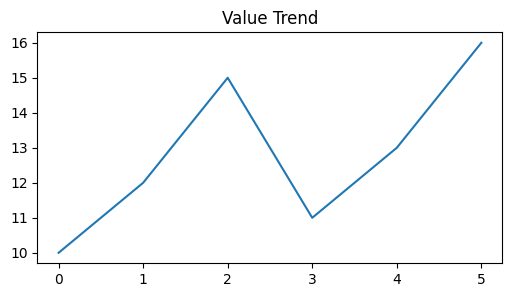

In [59]:
# Function: .plot(kind='line')
print("Simple line plot of 'Value':")
df_plot_data['Value'].plot(kind='line', title='Value Trend', figsize=(6,3))
plt.show()

Bar plot of 'Value' by index:


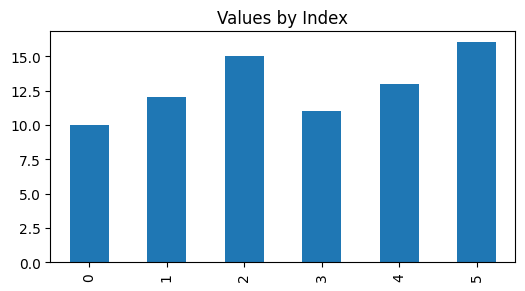

In [61]:
# Function: .plot(kind='bar')
print("Bar plot of 'Value' by index:")
df_plot_data['Value'].plot(kind = 'bar',title = 'Values by Index',figsize=(6,3))
plt.show()

Histogram of 'Value':


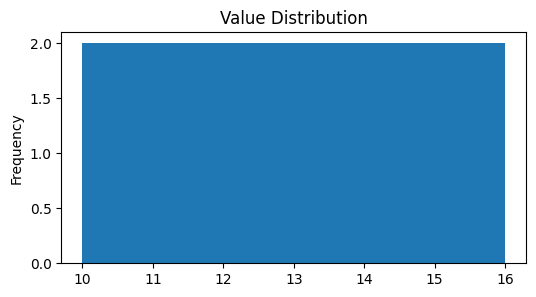

In [65]:
# Function: .plot(kind='hist')
print("Histogram of 'Value':")
df_plot_data['Value'].plot(kind='hist',bins=3,title='Value Distribution',figsize = (6,3))
plt.show()

In [66]:
# Category: Selection and Indexing
# Function: df['column_name']

print("Select a single column 'Product':")
display(df_products['Product'])

Select a single column 'Product':


0     Apple
1    Banana
2    Orange
Name: Product, dtype: str

In [67]:
print("Select multiple columns 'Product' and 'Price':")
display(df_products[['Product', 'Price']])

Select multiple columns 'Product' and 'Price':


,Product,Price
0,Apple,1.00
1,Banana,0.50
2,Orange,0.75


In [ ]:
# Function: .loc[] (Label-based indexing)
print("Select row with index 1 using .loc:")
display(df_products.loc[1])

print("Select 'Price' for 'Banana' (using boolean indexing with .loc):")
display(df_products.loc[df_products['Product'] == 'Banana', 'Price'])

Select row with index 1 using .loc:


Product     Banana
Price          0.5
Quantity       150
Name: 1, dtype: object

Select 'Price' for 'Banana' (using boolean indexing with .loc):


1    0.5
Name: Price, dtype: float64

In [69]:
# Function: .iloc[] (Integer-position-based indexing)
print("Select row at integer position 0 using .iloc:")
display(df_products.iloc[0])

print("Select Price and Quantity for the first two products using .iloc:")
display(df_products.iloc[0:2, 1:3])

Select row at integer position 0 using .iloc:


Product     Apple
Price         1.0
Quantity      100
Name: 0, dtype: object

Select Price and Quantity for the first two products using .iloc:


,Price,Quantity
0,1.0,100
1,0.5,150


In [70]:
# Category: Data Manipulation
# Function: df['new_column'] = value (Adding a new column)
df_manipulate = df_products.copy()
df_manipulate['Category'] = ['Fruit','Fruit','Fruit']
print("DataFrame after adding 'Category' column:")
display(df_manipulate)

DataFrame after adding 'Category' column:


,Product,Price,Quantity,Category
0,Apple,1.00,100,Fruit
1,Banana,0.50,150,Fruit
2,Orange,0.75,120,Fruit


In [71]:
df_manipulate['Price'] = df_manipulate['Price'] * 1.1
print("DataFrame after modifying 'Price' column:")
display(df_manipulate)

DataFrame after modifying 'Price' column:


,Product,Price,Quantity,Category
0,Apple,1.100,100,Fruit
1,Banana,0.550,150,Fruit
2,Orange,0.825,120,Fruit


In [72]:
# Function: df.drop(columns=['column_name']) (Deleting a column)
df_dropped_col = df_manipulate.drop(columns=['Category'])
print("DataFrame after dropping 'Category' column:")
display(df_dropped_col)

DataFrame after dropping 'Category' column:


,Product,Price,Quantity
0,Apple,1.100,100
1,Banana,0.550,150
2,Orange,0.825,120


In [74]:
# Function: df.drop(index=[row_label]) (Deleting a row)
df_dropped_row = df_manipulate.drop(index=0)
print("DataFrame after dropping row with index 0:")
display(df_dropped_row)

DataFrame after dropping row with index 0:


,Product,Price,Quantity,Category
1,Banana,0.550,150,Fruit
2,Orange,0.825,120,Fruit


In [75]:
# Category: Filtering Data
# Function: df[condition] (Boolean indexing for rows)
print("Products with Price greater than 0.8:")
display(df_manipulate[df_manipulate['Price'] > 0.8])


Products with Price greater than 0.8:


,Product,Price,Quantity,Category
0,Apple,1.100,100,Fruit
2,Orange,0.825,120,Fruit


In [79]:
# Function: df.query('condition') (Filtering using query method)
print("Products with Quantity less than 130 using .query():")
display(df_manipulate.query('Quantity < 130'))

Products with Quantity less than 130 using .query():


,Product,Price,Quantity,Category
0,Apple,1.100,100,Fruit
2,Orange,0.825,120,Fruit


In [80]:
# Category: Handling Missing Data
df_missing = pd.DataFrame({
    'A': [1, 2, np.nan, 4],
    'B': [np.nan, 6, 7, 8],
    'C': [9, 10, 11, np.nan]
})
print("Original DataFrame with missing values:")
display(df_missing)

Original DataFrame with missing values:


,A,B,C
0,1.0,NaN,9.0
1,2.0,6.0,10.0
2,NaN,7.0,11.0
3,4.0,8.0,NaN


In [81]:
# Function: .isnull() / .notnull()
print("Boolean DataFrame indicating missing values:")
display(df_missing.isnull())

Boolean DataFrame indicating missing values:


,A,B,C
0,False,True,False
1,False,False,False
2,True,False,False
3,False,False,True


In [84]:
# Function: .fillna()
print("DataFrame with missing values filled with 0:")
display(df_missing.fillna(0))

DataFrame with missing values filled with 0:


,A,B,C
0,1.0,0.0,9.0
1,2.0,6.0,10.0
2,0.0,7.0,11.0
3,4.0,8.0,0.0


In [85]:
# Function: .dropna()
print("DataFrame after dropping rows with any missing values:")
display(df_missing.dropna())

DataFrame after dropping rows with any missing values:


,A,B,C
1,2.0,6.0,10.0


In [86]:
# Category: Data Manipulation
# Function: df['new_column'] = value (Adding a new column)

df_manipulate = df_products.copy()
df_manipulate['Category'] = ['Fruit', 'Fruit', 'Fruit']
print("DataFrame after adding 'Category' column:")
display(df_manipulate)

DataFrame after adding 'Category' column:


,Product,Price,Quantity,Category
0,Apple,1.00,100,Fruit
1,Banana,0.50,150,Fruit
2,Orange,0.75,120,Fruit
